# Genome-wide coverage (CNV) plot

Shows normalised read depth in fixed genomic windows for all 6 edited clones (B1–B6)
relative to the unmodified control (C8).  
Flat log2-ratio lines near 0 = no large-scale copy-number changes or translocations.

**Strategy**: stream each BAM from S3 through `samtools view -b | mosdepth --by 500000`  
to avoid downloading full BAMs (~130 MB each) onto the near-full disk.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

S3_RESULTS = "s3://compbio-discovery-shared/nonLTR/wgs/mosdepth_500kb"

CLONES  = ["B1", "B2", "B3", "B4", "B5", "B6"]
CONTROL = "C8"
ALL_SAMPLES = [CONTROL] + CLONES

BIN_SIZE = 500_000   # 500 kb windows

OUT_DIR = Path("/home/ec2-user/cnv_data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT_DIR)
print("Samples:", ALL_SAMPLES)

Output directory: /home/ec2-user/cnv_data
Samples: ['C8', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6']


In [2]:
import subprocess

def download_mosdepth(sample_id):
    """Download regions.bed.gz from S3 if not already present."""
    sample_name = f"GM25256-{sample_id}" if sample_id != "C8" else "GM25256-C8"
    local = OUT_DIR / f"{sample_name}.regions.bed.gz"
    if local.exists():
        print(f"  {sample_id}: already downloaded")
        return local
    s3_path = f"{S3_RESULTS}/{sample_name}.regions.bed.gz"
    print(f"  {sample_id}: downloading from S3 ...", end=" ", flush=True)
    r = subprocess.run(["aws", "s3", "cp", s3_path, str(local)],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"Download failed for {sample_id}: {r.stderr.strip()[:200]}")
    print(f"OK ({local.stat().st_size/1e6:.1f} MB)")
    return local

print("Downloading mosdepth results from S3 ...\n")
for s in ALL_SAMPLES:
    download_mosdepth(s)
print("\nDone.")


  C8: already downloaded
  B1: already downloaded
  B2: already downloaded
  B3: already downloaded
  B4: already downloaded
  B5: already downloaded
  B6: already downloaded

Done.


In [3]:
CHROM_KEEP = {f"chr{i}" for i in range(1, 23)} | {"chrX"}
CHROM_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

depth = {}
for s in ALL_SAMPLES:
    sample_name = f"GM25256-{s}"
    f = OUT_DIR / f"{sample_name}.regions.bed.gz"
    df = pd.read_csv(f, sep="\t", header=None,
                     names=["chrom", "start", "end", "depth"],
                     compression="gzip")
    df = df[df["chrom"].isin(CHROM_KEEP)].copy()
    df["mid"]    = (df["start"] + df["end"]) // 2
    df["sample"] = s
    depth[s] = df
    print(f"  {s}: {len(df):,} bins, median depth {df['depth'].median():.1f}")

for s, df in depth.items():
    med = df["depth"].median()
    df["norm"] = df["depth"] / med if med > 0 else df["depth"]

ctrl = depth[CONTROL].set_index(["chrom", "start"])["norm"].rename("ctrl_norm")
print(f"\nControl ({CONTROL}) loaded.")

  C8: 6,073 bins, median depth 75.8
  B1: 6,073 bins, median depth 74.2
  B2: 6,073 bins, median depth 82.0
  B3: 6,073 bins, median depth 84.9
  B4: 6,073 bins, median depth 82.5
  B5: 6,073 bins, median depth 80.0
  B6: 6,073 bins, median depth 71.5

Control (C8) loaded.


In [4]:
# ── Download GC + N-fraction content table ────────────────────────────────
gc_local = OUT_DIR / "hg38_500kb_gc.tsv"
print("Downloading GC content table from S3 ...", end=" ", flush=True)
r = subprocess.run(["aws", "s3", "cp",
                    f"{S3_RESULTS}/hg38_500kb_gc.tsv", str(gc_local)],
                   capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError(f"GC download failed: {r.stderr.strip()[:200]}")
print("OK")

gc_df = pd.read_csv(gc_local, sep="\t")
has_nfrac = "n_frac" in gc_df.columns
gc_df = gc_df[gc_df["chrom"].isin(CHROM_KEEP)].copy()
gc_index = gc_df.set_index(["chrom", "start"])["gc_frac"]
n_index  = gc_df.set_index(["chrom", "start"])["n_frac"] if has_nfrac else None

# ── hg38 centromere coordinates (from UCSC cytoBand) ──────────────────────
# Pericentromeric regions are alpha-satellite / low-complexity sequence
# where reads map ambiguously, producing stochastic library-dependent
# coverage spikes that are NOT true CNVs.
HG38_CENTROMERES = {
    "chr1":  (122026459, 125184587),
    "chr2":  ( 92188145,  94090557),
    "chr3":  ( 90772458,  93655574),
    "chr4":  ( 49708101,  51743951),
    "chr5":  ( 46485900,  50059807),
    "chr6":  ( 58553888,  59829934),
    "chr7":  ( 58169653,  60828234),
    "chr8":  ( 44033744,  45877265),
    "chr9":  ( 43236168,  45518558),
    "chr10": ( 39686682,  41593521),
    "chr11": ( 51078348,  54425074),
    "chr12": ( 34769407,  37185252),
    "chr13": ( 16000000,  18051248),
    "chr14": ( 16000000,  18173523),
    "chr15": ( 17083673,  19725254),
    "chr16": ( 36311158,  38265669),
    "chr17": ( 22813679,  26616164),
    "chr18": ( 15460898,  20861206),
    "chr19": ( 24498980,  27190874),
    "chr20": ( 26436232,  28494539),
    "chr21": ( 10864560,  12915808),
    "chr22": ( 13684473,  17805839),
    "chrX":  ( 58605499,  62412542),
}
PERICENTRIC_BUFFER = 3_000_000  # mask ±3 Mb around centromere

def is_pericentric(chrom, start, end):
    if chrom not in HG38_CENTROMERES:
        return False
    c_lo, c_hi = HG38_CENTROMERES[chrom]
    return (end >= c_lo - PERICENTRIC_BUFFER) and (start <= c_hi + PERICENTRIC_BUFFER)

# ── Filters ────────────────────────────────────────────────────────────────
N_FRAC_MAX  = 0.10              # mask assembly gaps
DEPTH_PCTILE_HI = 99            # mask extreme depth outliers (segmental dups etc.)
N_GC_BINS   = 50

def normalise_sample(df, label):
    df = df.copy()
    df = df.set_index(["chrom", "start"])
    df["gc"] = df.index.map(gc_index)
    df["n_frac"] = df.index.map(n_index) if has_nfrac else 0.0
    df = df.reset_index()

    n_start = len(df)
    df = df[df["n_frac"] <= N_FRAC_MAX]

    # Pericentromeric mask
    pericentric_mask = df.apply(
        lambda r: is_pericentric(r["chrom"], r["start"], r["end"]), axis=1
    )
    df = df[~pericentric_mask]

    # Depth outlier mask — per-sample 99th percentile (catches segmental dup artefacts)
    depth_hi = np.percentile(df["depth"], DEPTH_PCTILE_HI)
    df = df[df["depth"] <= depth_hi]

    # Drop bins with missing GC (shouldn't happen after N filter, but safe)
    df = df.dropna(subset=["gc"])

    # GC normalisation
    df["gc_bin"] = pd.cut(df["gc"], bins=N_GC_BINS, labels=False)
    gc_median = df.groupby("gc_bin")["depth"].median()
    df["gc_expected"] = df["gc_bin"].map(gc_median)
    global_median = df["depth"].median()
    df["norm_gc"] = df["depth"] / df["gc_expected"] * global_median

    n_end = len(df)
    cv_before = df["depth"].std() / df["depth"].mean()
    cv_after  = df["norm_gc"].std() / df["norm_gc"].mean()
    print(f"  {label}: {n_start}→{n_end} bins, CV {cv_before:.3f} → {cv_after:.3f}")
    return df

print(f"Filters: N≤{N_FRAC_MAX}, pericentric ±{PERICENTRIC_BUFFER//1_000_000}Mb, depth≤{DEPTH_PCTILE_HI}th pctile")
print("Applying normalisation ...\n", flush=True)
depth_gc = {}
for s in ALL_SAMPLES:
    depth_gc[s] = normalise_sample(depth[s], s)

ctrl_gc = depth_gc[CONTROL].set_index(["chrom", "start"])["norm_gc"].rename("ctrl_norm_gc")
print("\nNormalisation complete.")

OK
Filters: N≤0.1, pericentric ±3Mb, depth≤99th pctile
Applying normalisation ...



  C8: 6073→5592 bins, CV 0.256 → 0.128
  B1: 6073→5592 bins, CV 0.317 → 0.139
  B2: 6073→5592 bins, CV 0.240 → 0.129


  B3: 6073→5592 bins, CV 0.243 → 0.126
  B4: 6073→5592 bins, CV 0.241 → 0.126


  B5: 6073→5592 bins, CV 0.373 → 0.150
  B6: 6073→5592 bins, CV 0.229 → 0.122

Normalisation complete.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

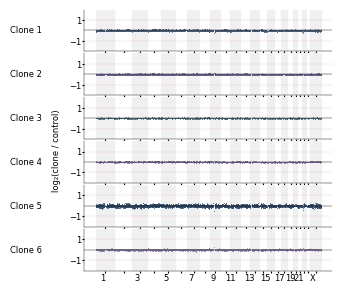

Saved → /home/ec2-user/cnv_data/cnv_log2ratio_gc_norm.pdf and ../artifacts/cnv_log2ratio_gc_norm.svg


In [20]:
# ── Genome-wide log2-ratio plot — compact panel (GC-normalised, median-centered)
PALETTE = [
    "#3d5a80", "#6b5b95", "#4a6877", "#7d6b9e",
    "#2d4a6b", "#8a7aad",
]
PSEUDO = 0.01

import warnings
import matplotlib
matplotlib.rcParams["font.family"] = "Arial"
matplotlib.rcParams["font.size"]   = 6
warnings.filterwarnings("ignore", message="findfont")

FIG_W, FIG_H = 4, 3   # inches

fig, axes = plt.subplots(len(CLONES), 1, figsize=(FIG_W, FIG_H), sharex=True)
plt.subplots_adjust(hspace=0.05, left=0.35, right=0.97, top=0.97, bottom=0.10)

chrom_offsets = {}
offset = 0
chrom_mids_for_ticks = {}
for ch in CHROM_ORDER:
    bins_ch = depth_gc[CONTROL][depth_gc[CONTROL]["chrom"] == ch]
    if bins_ch.empty:
        continue
    chrom_offsets[ch] = offset
    chrom_mids_for_ticks[ch] = offset + bins_ch["mid"].median()
    offset += bins_ch["end"].max()

def genomic_x(df):
    return df["mid"] + df["chrom"].map(chrom_offsets)

for ax_i, (clone, color) in enumerate(zip(CLONES, PALETTE)):
    ax = axes[ax_i]
    df = depth_gc[clone].copy()
    merged = df.join(ctrl_gc, on=["chrom", "start"])
    merged = merged.dropna(subset=["ctrl_norm_gc"])

    log2r = np.log2((merged["norm_gc"] + PSEUDO) / (merged["ctrl_norm_gc"] + PSEUDO))
    log2r = log2r - log2r.median()
    gx = genomic_x(merged)

    for ci, ch in enumerate(CHROM_ORDER):
        if ch not in chrom_offsets:
            continue
        ch_df = merged[merged["chrom"] == ch]
        if ch_df.empty:
            continue
        x0 = chrom_offsets[ch]
        x1 = x0 + ch_df["end"].max()
        if ci % 2 == 0:
            ax.axvspan(x0, x1, color="#f0f0f0", zorder=0)

    ax.scatter(gx, log2r, s=0.5, color=color, alpha=0.6, linewidths=0, zorder=2)
    ax.axhline(0, color="black", linewidth=0.3, zorder=3)
    ax.axhline( 1, color="#cc3333", linewidth=0.2, linestyle="--", alpha=0.5, zorder=3)
    ax.axhline(-1, color="#cc3333", linewidth=0.2, linestyle="--", alpha=0.5, zorder=3)
    ax.set_ylim(-2, 2)
    ax.set_yticks([-1, 1])
    ax.tick_params(axis="y", labelsize=6, length=1.5, pad=1)
    ax.tick_params(axis="x", labelsize=6, length=1.5, pad=1)
    ax.spines[["top", "right"]].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.3)

    # Clone label: far left of supylabel
    ax.text(-0.3, 0.5, f"Clone {clone[1:]}", transform=ax.transAxes,
            fontsize=6, va="center", ha="left")

tick_positions = list(chrom_mids_for_ticks.values())
tick_labels = [ch.replace("chr", "") for ch in chrom_mids_for_ticks]
sparse_labels = [lbl if i % 2 == 0 else "" for i, lbl in enumerate(tick_labels)]

axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(sparse_labels, fontsize=6, ha="right")

# supylabel close to y-axis
fig.supylabel("log₂(clone / control)", fontsize=6, x=0.27)

out = "/home/ec2-user/cnv_data/cnv_log2ratio_gc_norm.pdf"
plt.savefig(out, dpi=300)
with plt.rc_context({"svg.fonttype": "none"}):
    plt.savefig("../artifacts/cnv_log2ratio_gc_norm.svg")
plt.show()
print(f"Saved → {out} and ../artifacts/cnv_log2ratio_gc_norm.svg")

In [6]:
# ── Identify top peaks (after GC normalisation) ───────────────────────────
print("Top 10 |log2-ratio| peaks per sample:\n")
for clone in CLONES:
    df = depth_gc[clone].copy()
    merged = df.join(ctrl_gc, on=["chrom", "start"]).dropna(subset=["ctrl_norm_gc"])
    merged["log2r"] = np.log2(
        (merged["norm_gc"] + PSEUDO) / (merged["ctrl_norm_gc"] + PSEUDO)
    )
    merged["abs_l2"] = merged["log2r"].abs()
    top = merged.nlargest(10, "abs_l2")[["chrom", "start", "end", "gc", "depth", "log2r"]]
    print(f"=== {clone} ===")
    print(top.to_string(index=False))
    print()

# Shared peaks across B1 and B5
print("\n\n=== Peaks present in BOTH B1 and B5 (|log2r|>0.5 in both) ===")
def l2r(s):
    df = depth_gc[s].join(ctrl_gc, on=["chrom", "start"]).dropna(subset=["ctrl_norm_gc"])
    df["log2r"] = np.log2((df["norm_gc"] + PSEUDO) / (df["ctrl_norm_gc"] + PSEUDO))
    return df.set_index(["chrom", "start"])["log2r"]

b1 = l2r("B1")
b5 = l2r("B5")
b3 = l2r("B3")
shared = pd.DataFrame({"B1": b1, "B5": b5, "B3": b3}).dropna()
both_high = shared[(shared["B1"].abs() > 0.5) & (shared["B5"].abs() > 0.5)]
print(both_high.sort_values("B1", ascending=False).head(20).to_string())

Top 10 |log2-ratio| peaks per sample:

=== B1 ===
chrom     start       end       gc  depth     log2r
 chr9  60500000  61000000 0.390508  46.91 -0.316662
chr21   5000000   5500000 0.459221  56.73 -0.259061
chr21   7000000   7500000 0.400533  54.75 -0.219329
chr16  32500000  33000000 0.422300  60.81 -0.191313
 chr9  65000000  65500000 0.439169  43.48 -0.167236
 chrX  99000000  99500000 0.358350  25.25 -0.163642
 chr8 138500000 139000000 0.453912  72.53 -0.158070
 chr4  11000000  11500000 0.400780  61.19 -0.155913
 chrX  99500000 100000000 0.361584  25.53 -0.155533
chr14  79000000  79500000 0.383924  63.97 -0.153557

=== B2 ===
chrom     start       end       gc  depth    log2r
 chr4  92500000  93000000 0.342296  85.66 0.260002
 chr9  60500000  61000000 0.390508  70.93 0.254953
 chr5   7000000   7500000 0.402928  88.81 0.235962
chr12  59000000  59500000 0.363464  82.39 0.233112
 chr4  92000000  92500000 0.355708  89.43 0.230731
chr12  59500000  60000000 0.362394  77.55 0.224414
 chr7 112